# Análisis de Componentes Principales


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

plt.style.use('ggplot')

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [ ]:
features = ['budget', 'revenue', 'runtime', 'voteAvg', 'voteCount', 'popularity']

df_pca = df[features].dropna()
df_pca = df_pca[(df_pca['budget'] > 1000) & (df_pca['revenue'] > 1000)]

print(f"Data ready for PCA. Rows: {len(df_pca)}")

# Estandarización de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)
df_scaled = pd.DataFrame(X_scaled, columns=features)

display(df_scaled.head())

Data ready for PCA. Rows: 4394


,budget,revenue,runtime,voteAvg,voteCount,popularity
0,-0.800071,-0.527894,0.694706,1.367460,-0.765714,0.056122
1,-0.155132,-0.512429,4.139954,1.270745,-0.773933,-0.105656
2,-0.004646,-0.478114,0.136017,0.580245,-0.746339,0.225501
3,-0.370111,-0.520645,-0.189885,-1.513748,-0.752504,-0.066747
4,-0.843282,-0.606600,-0.608902,-7.404366,-0.775988,-0.182851


**Selección y estandarización de variables**

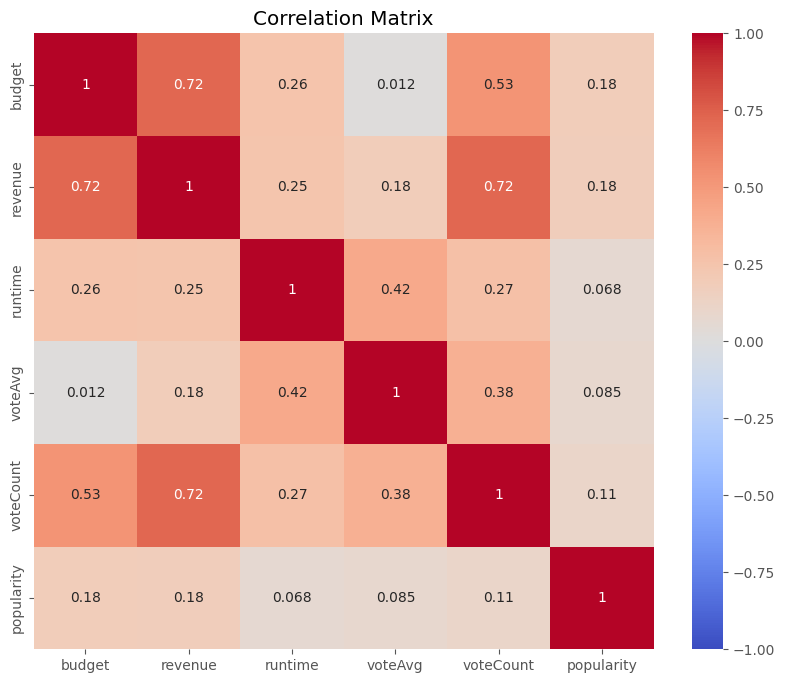

Observation: Look for high correlations (dark red/blue).
Example: Budget and Revenue usually have high correlation, making them good candidates for reduction.


In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df_scaled.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.show()

**Visualización de correlaciones entre variables**

In [ ]:
# Test de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print(f"Bartlett's Test p-value: {p_value}")
if p_value < 0.05:
    print("-> Las variables están correlacionadas (apto para PCA)")
else:
    print("-> Las variables son independientes (PCA no recomendado)")

# Test KMO
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"\nKMO Test Value: {kmo_model:.4f}")
if kmo_model > 0.6:
    print("-> Muestreo adecuado para PCA")
else:
    print("-> KMO bajo, resultados pueden no ser confiables")

Bartlett's Test p-value: 0.0
-> PASS: Variables are correlated enough for PCA.
KMO Test Value: 0.6582
-> PASS: Sampling is adequate (Value > 0.6).


**Pruebas de idoneidad para PCA**

,Component,Variance Explained,Cumulative Variance
0,PC1,0.438982,0.438982
1,PC2,0.201740,0.640722
2,PC3,0.158532,0.799255
3,PC4,0.113164,0.912419
4,PC5,0.052613,0.965033
5,PC6,0.034967,1.000000


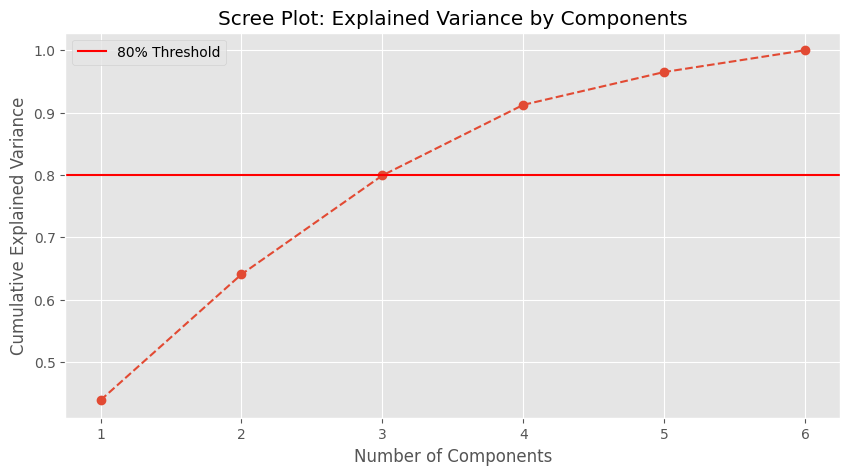

Analysis: Choose the number of components where the line crosses 0.8 (80%) or flattens out.


In [ ]:
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(features))],
    'Variance Explained': explained_variance,
    'Cumulative Variance': cumulative_variance
})

display(pca_summary)

# Gráfico de sedimentación
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(features) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.8, color='r', linestyle='-', label='Umbral 80%')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Gráfico de Codo: Varianza Explicada')
plt.legend()
plt.show()

**Aplicación de PCA y análisis de varianza explicada**

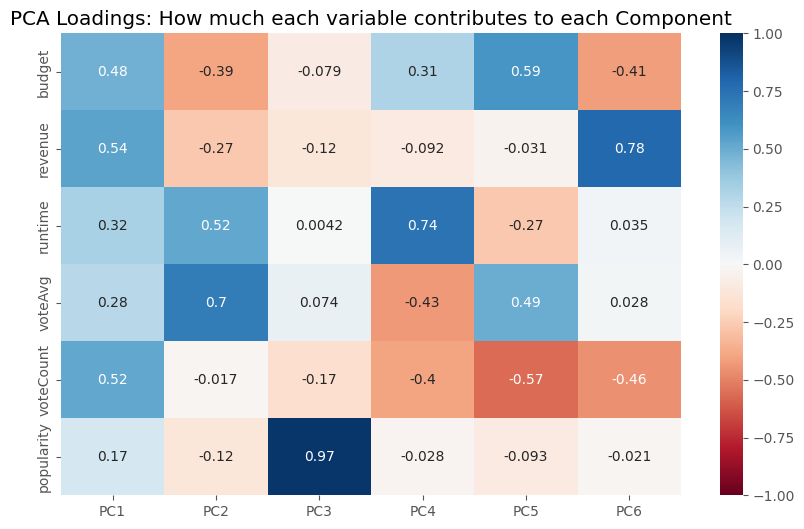

Interpretation Guide:
- High positive value (Red): Variable strongly increases this component.
- High negative value (Blue): Variable strongly decreases this component.
- Example: If PC1 has high positive Budget, Revenue, and VoteCount, PC1 represents 'Blockbuster Scale'.


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(features))], 
    index=features
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title("Cargas de PCA: Contribución de cada variable")
plt.show()

**Interpretación de las cargas de componentes principales**